In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus']=False

In [2]:
customers_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_customers_dataset.csv')
geolocation_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_geolocation_dataset.csv')
items_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_order_items_dataset.csv')
payments_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_order_payments_dataset.csv')
reviews_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_orders_dataset.csv')
products_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_products_dataset.csv')
sellers_df = pd.read_csv('/Users/minhapark/Desktop/sql_project/archive/olist_sellers_dataset.csv')

In [3]:
# orders와 reviews 합치기 (order_id 기준)
merged_df = pd.merge(orders_df, reviews_df, on="order_id", how="inner")

# 배송 완료건만 필터링
merged_df = merged_df[merged_df['order_delivered_customer_date'].notna()].copy()

# 날짜 차이 계산
merged_df['delivery_diff'] = (
    pd.to_datetime(merged_df['order_delivered_customer_date']) - 
    pd.to_datetime(merged_df['order_estimated_delivery_date'])
).dt.days

# 배송 상태 라벨링
merged_df['delivery_status'] = merged_df['delivery_diff'].apply(
    lambda x: "지연" if x > 0 else "조기"
)

# 리뷰 점수 1점,2점 준 고객만 필터링
low_core = merged_df[(merged_df['review_score'] == 1) | (merged_df['review_score'] == 2)]

# 배송 상태 비율 계산
status_counts = low_core['delivery_status'].value_counts(normalize=True) * 100
print(status_counts)

delivery_status
조기    67.611336
지연    32.388664
Name: proportion, dtype: float64


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1184/1305310755.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_core[col] = pd.to_datetime(low_core[col], errors='coerce')
/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1184/1305310755.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_core[col] = pd.to_datetime(low_core[col], errors='coerce')
/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1184/1305310755.py:10: SettingWithCopyWarning: 
A value is trying to be s

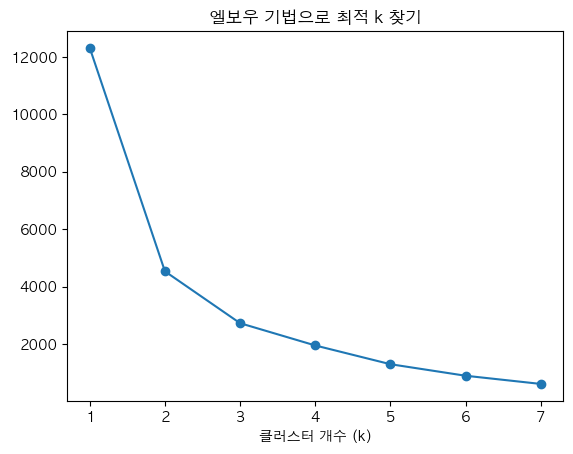

In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# === 1) 날짜 컬럼 datetime 변환 ===
date_cols = ['order_delivered_customer_date', 'order_purchase_timestamp']
for col in date_cols:
    low_core[col] = pd.to_datetime(low_core[col], errors='coerce')

# === 2) 배송일 계산 ===
low_core['delivery_days'] = (low_core['order_delivered_customer_date'] - low_core['order_purchase_timestamp']).dt.days

# === 3) 고객별 평균 배송일 계산 ===
customer_delivery = low_core.groupby('customer_id')['delivery_days'].mean().reset_index()

# === 4) NaN 제거 ===
customer_delivery = customer_delivery.dropna()

# === 5) 데이터 스케일링 ===
X = customer_delivery[['delivery_days']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 6) 엘보우 기법으로 최적 k 찾기 ===
inertia = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("클러스터 개수 (k)")
plt.title("엘보우 기법으로 최적 k 찾기")
plt.savefig('엘보우로 k 찾기_최종', dpi=600)
plt.show()

In [5]:
import geopandas as gpd
import matplotlib as mpl

/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1184/1191827810.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis', 3)


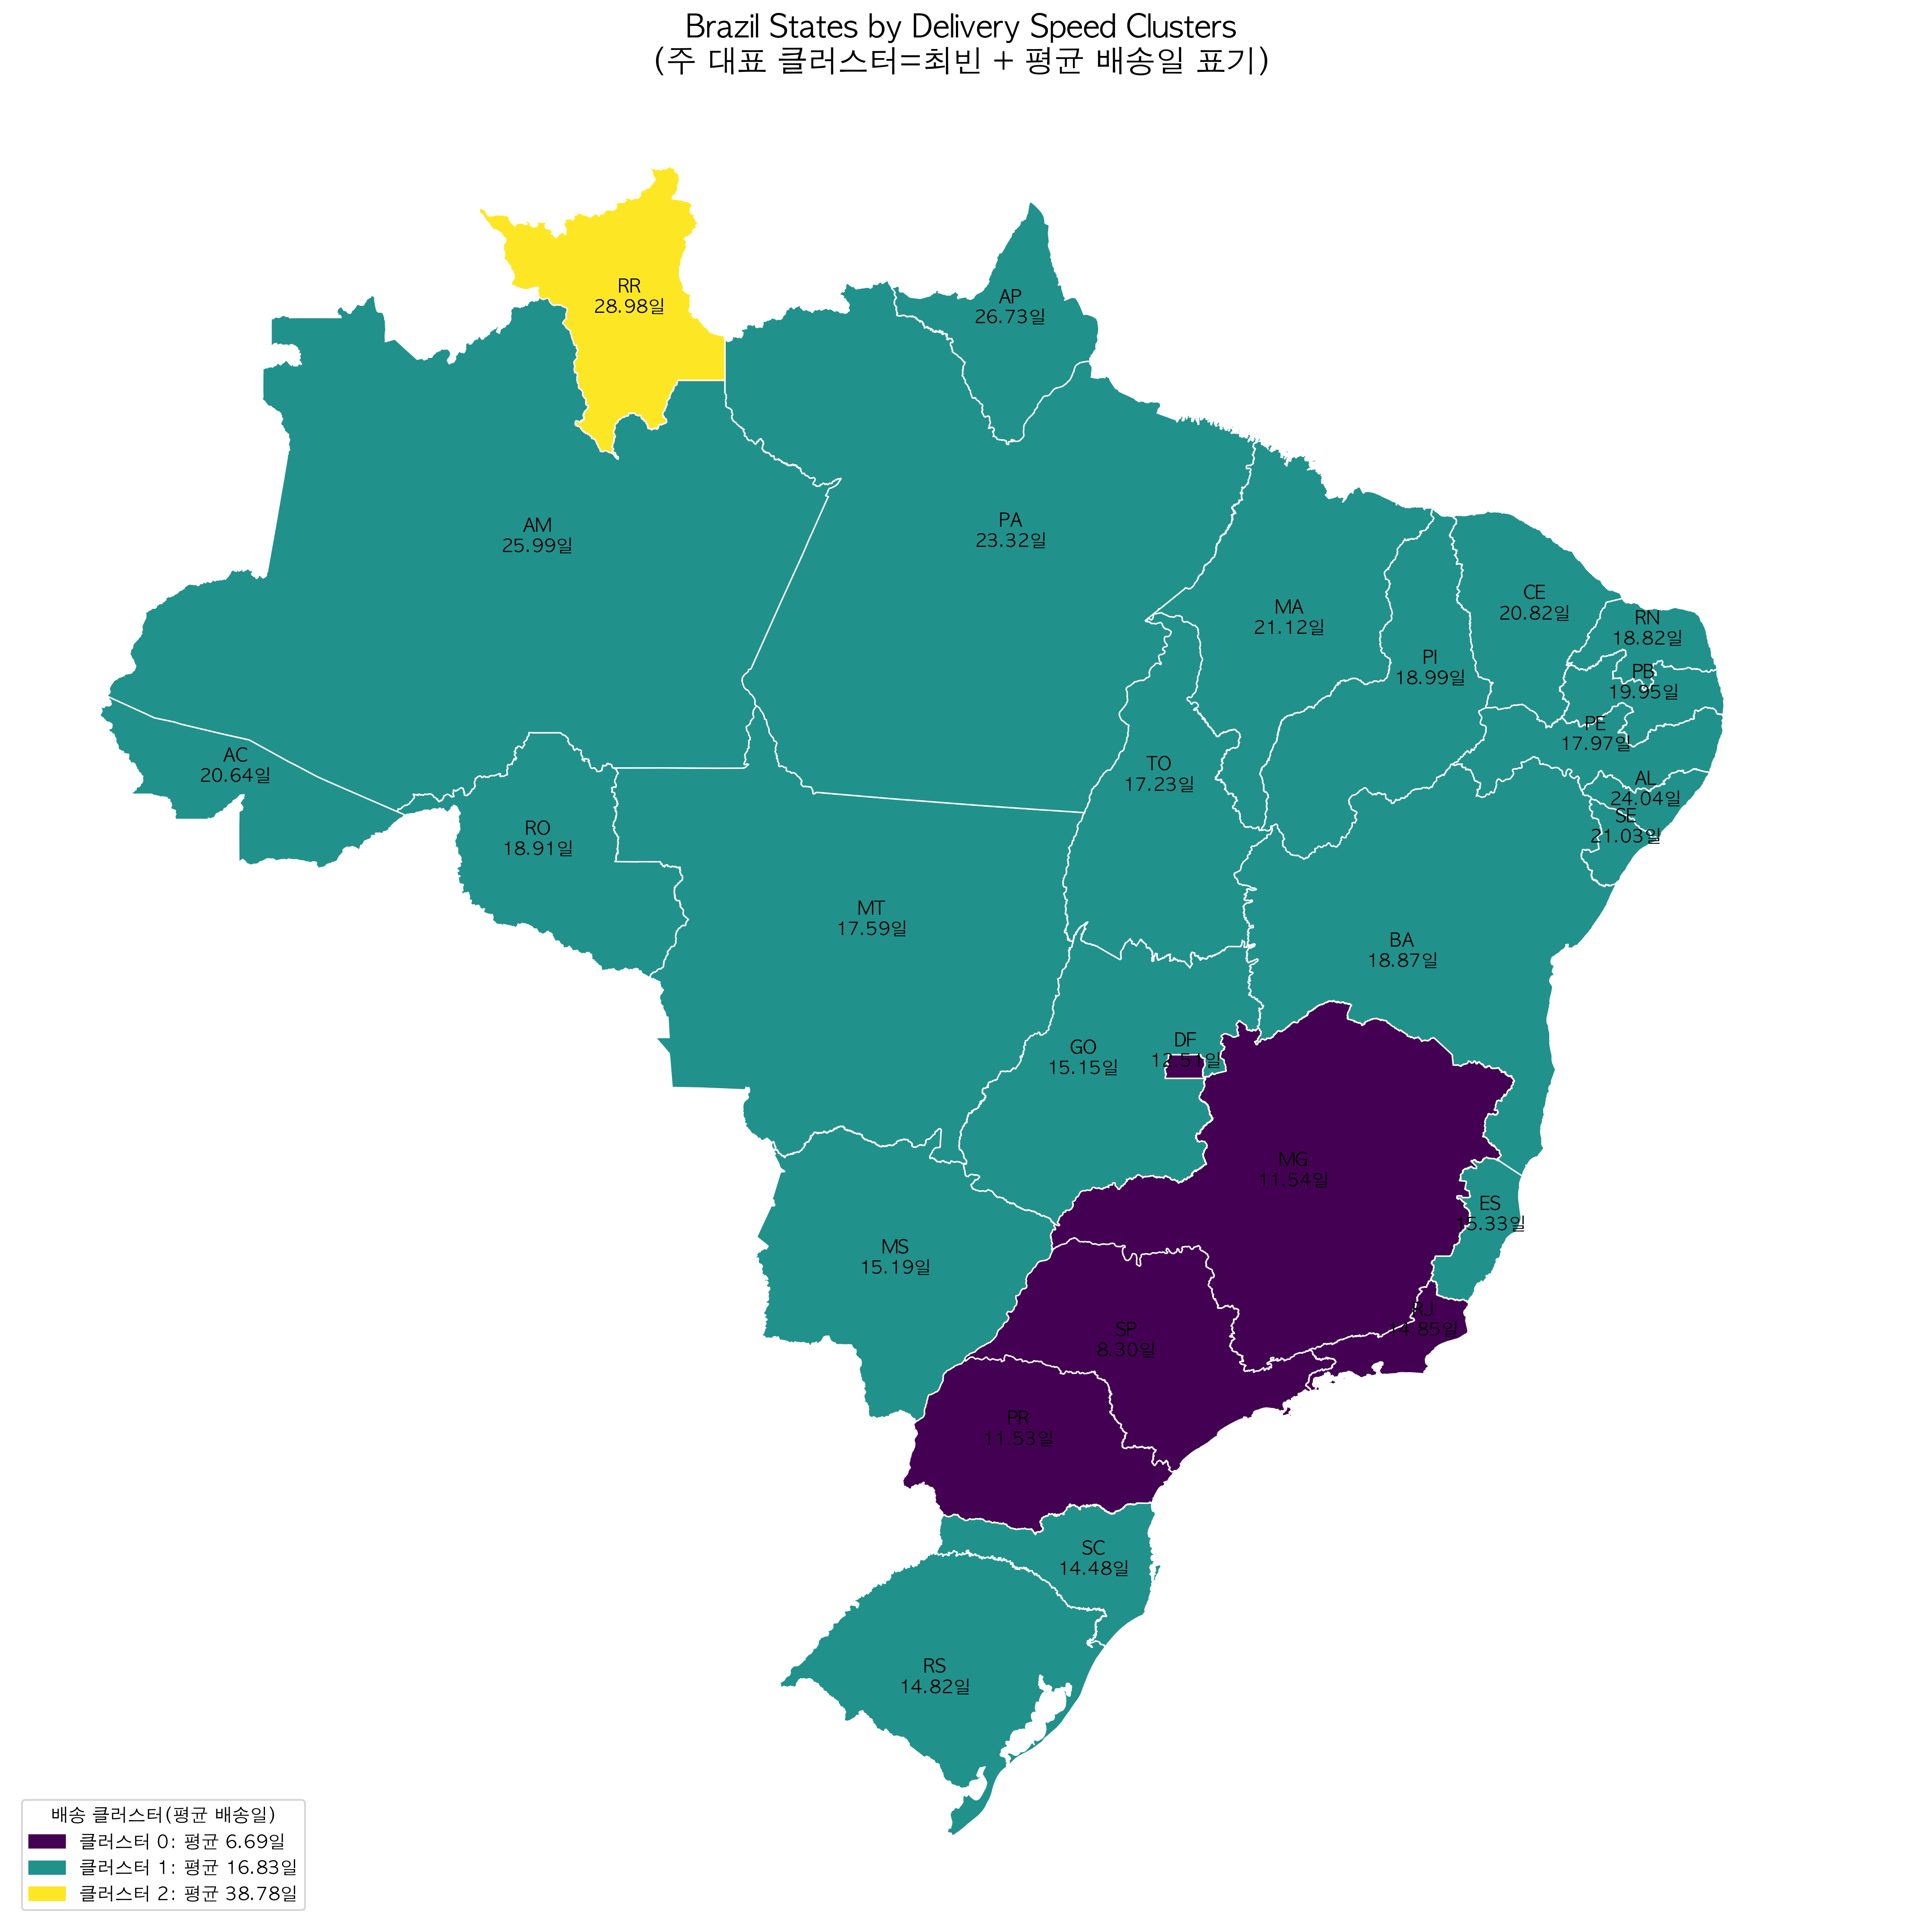

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ===============================
# 0) 브라질 주 경계 (두 글자 주코드: 'state')
# ===============================
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil = gpd.read_file(url).rename(columns={'sigla': 'state'})

# ===============================
# 1) 날짜 컬럼 변환 + 배송일 계산 (orders_df)
# ===============================
orders = orders_df.copy()
for col in ['order_purchase_timestamp', 'order_delivered_customer_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# 고객별 평균 배송일
customer_delivery = (
    orders.groupby('customer_id', as_index=False)['delivery_days']
          .mean()
          .dropna(subset=['delivery_days'])
)

# ===============================
# 2) 고객 → 주(state) 붙이기 (customer_df)
# ===============================
id_state = (
    customers_df[['customer_id', 'customer_state']]
    .dropna()
    .drop_duplicates()
)

cd_with_state = customer_delivery.merge(id_state, on='customer_id', how='left')
cd_with_state = cd_with_state.dropna(subset=['customer_state'])

# ===============================
# 3) KMeans(3)로 고객 클러스터링
# ===============================
X = cd_with_state[['delivery_days']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
cd_with_state['cluster'] = kmeans.fit_predict(X_scaled)

# ===============================
# 4) 클러스터별 평균 배송일(범례용, 둘째자리)
# ===============================
cluster_summary = (
    cd_with_state.groupby('cluster')['delivery_days']
    .mean()
    .reset_index()
)

# ===============================
# 5) 주(state) 단위 집계
#    - 대표 클러스터: 최빈값(mode)
#    - 평균 배송일: mean
# ===============================
def mode_cluster(s):
    return s.value_counts().idxmax()

state_agg = (
    cd_with_state.groupby('customer_state')
    .agg(
        state_cluster=('cluster', mode_cluster),
        avg_delivery_days=('delivery_days', 'mean'),
        n_customers=('customer_id', 'nunique')
    )
    .reset_index()
    .rename(columns={'customer_state': 'state'})
)

# ===============================
# 6) 지오데이터 병합
# ===============================
merged = brazil.merge(state_agg, on='state', how='left')
merged_with_data = merged[~merged['state_cluster'].isna()].copy()

# ===============================
# 7) 지도 시각화 (3그룹 색상 + 평균일자 텍스트 + 범례)
# ===============================
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)

# 회색 베이스
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

# 색칠
cmap = mpl.cm.get_cmap('viridis', 3)
merged_with_data.plot(
    column='state_cluster',
    cmap=cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=False,
    categorical=True
)

# 주 코드 + 평균 배송일(둘째자리) 텍스트
for _, row in merged_with_data.iterrows():
    rep_pt = row['geometry'].representative_point()
    ax.text(
        rep_pt.x, rep_pt.y,
        f"{row['state']}\n{row['avg_delivery_days']:.2f}일",
        fontsize=10, ha='center', weight='bold'
    )

# 커스텀 범례: "클러스터 n: 평균 XX.XX일"
handles = []
N = 3
for _, r in cluster_summary.iterrows():
    c = int(r['cluster'])
    color = cmap(c/(N-1))   # 0,1,2 → 0.0, 0.5, 1.0
    handles.append(
        mpatches.Patch(
            color=color,
            label=f"클러스터 {c}: 평균 {r['delivery_days']:.2f}일"
        )
    )
ax.legend(handles=handles, title="배송 클러스터(평균 배송일)", loc='lower left')

plt.title("Brazil States by Delivery Speed Clusters\n(주 대표 클러스터=최빈 + 평균 배송일 표기)", fontsize=17)
ax.axis('off')
plt.tight_layout()
plt.show()


In [15]:
from sklearn.linear_model import HuberRegressor
from math import radians, sin, cos, asin, sqrt 

In [17]:
items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


/var/folders/3h/sws6lkk531531_b2dzm5hbbw0000gn/T/ipykernel_1184/1263606441.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis', 3)


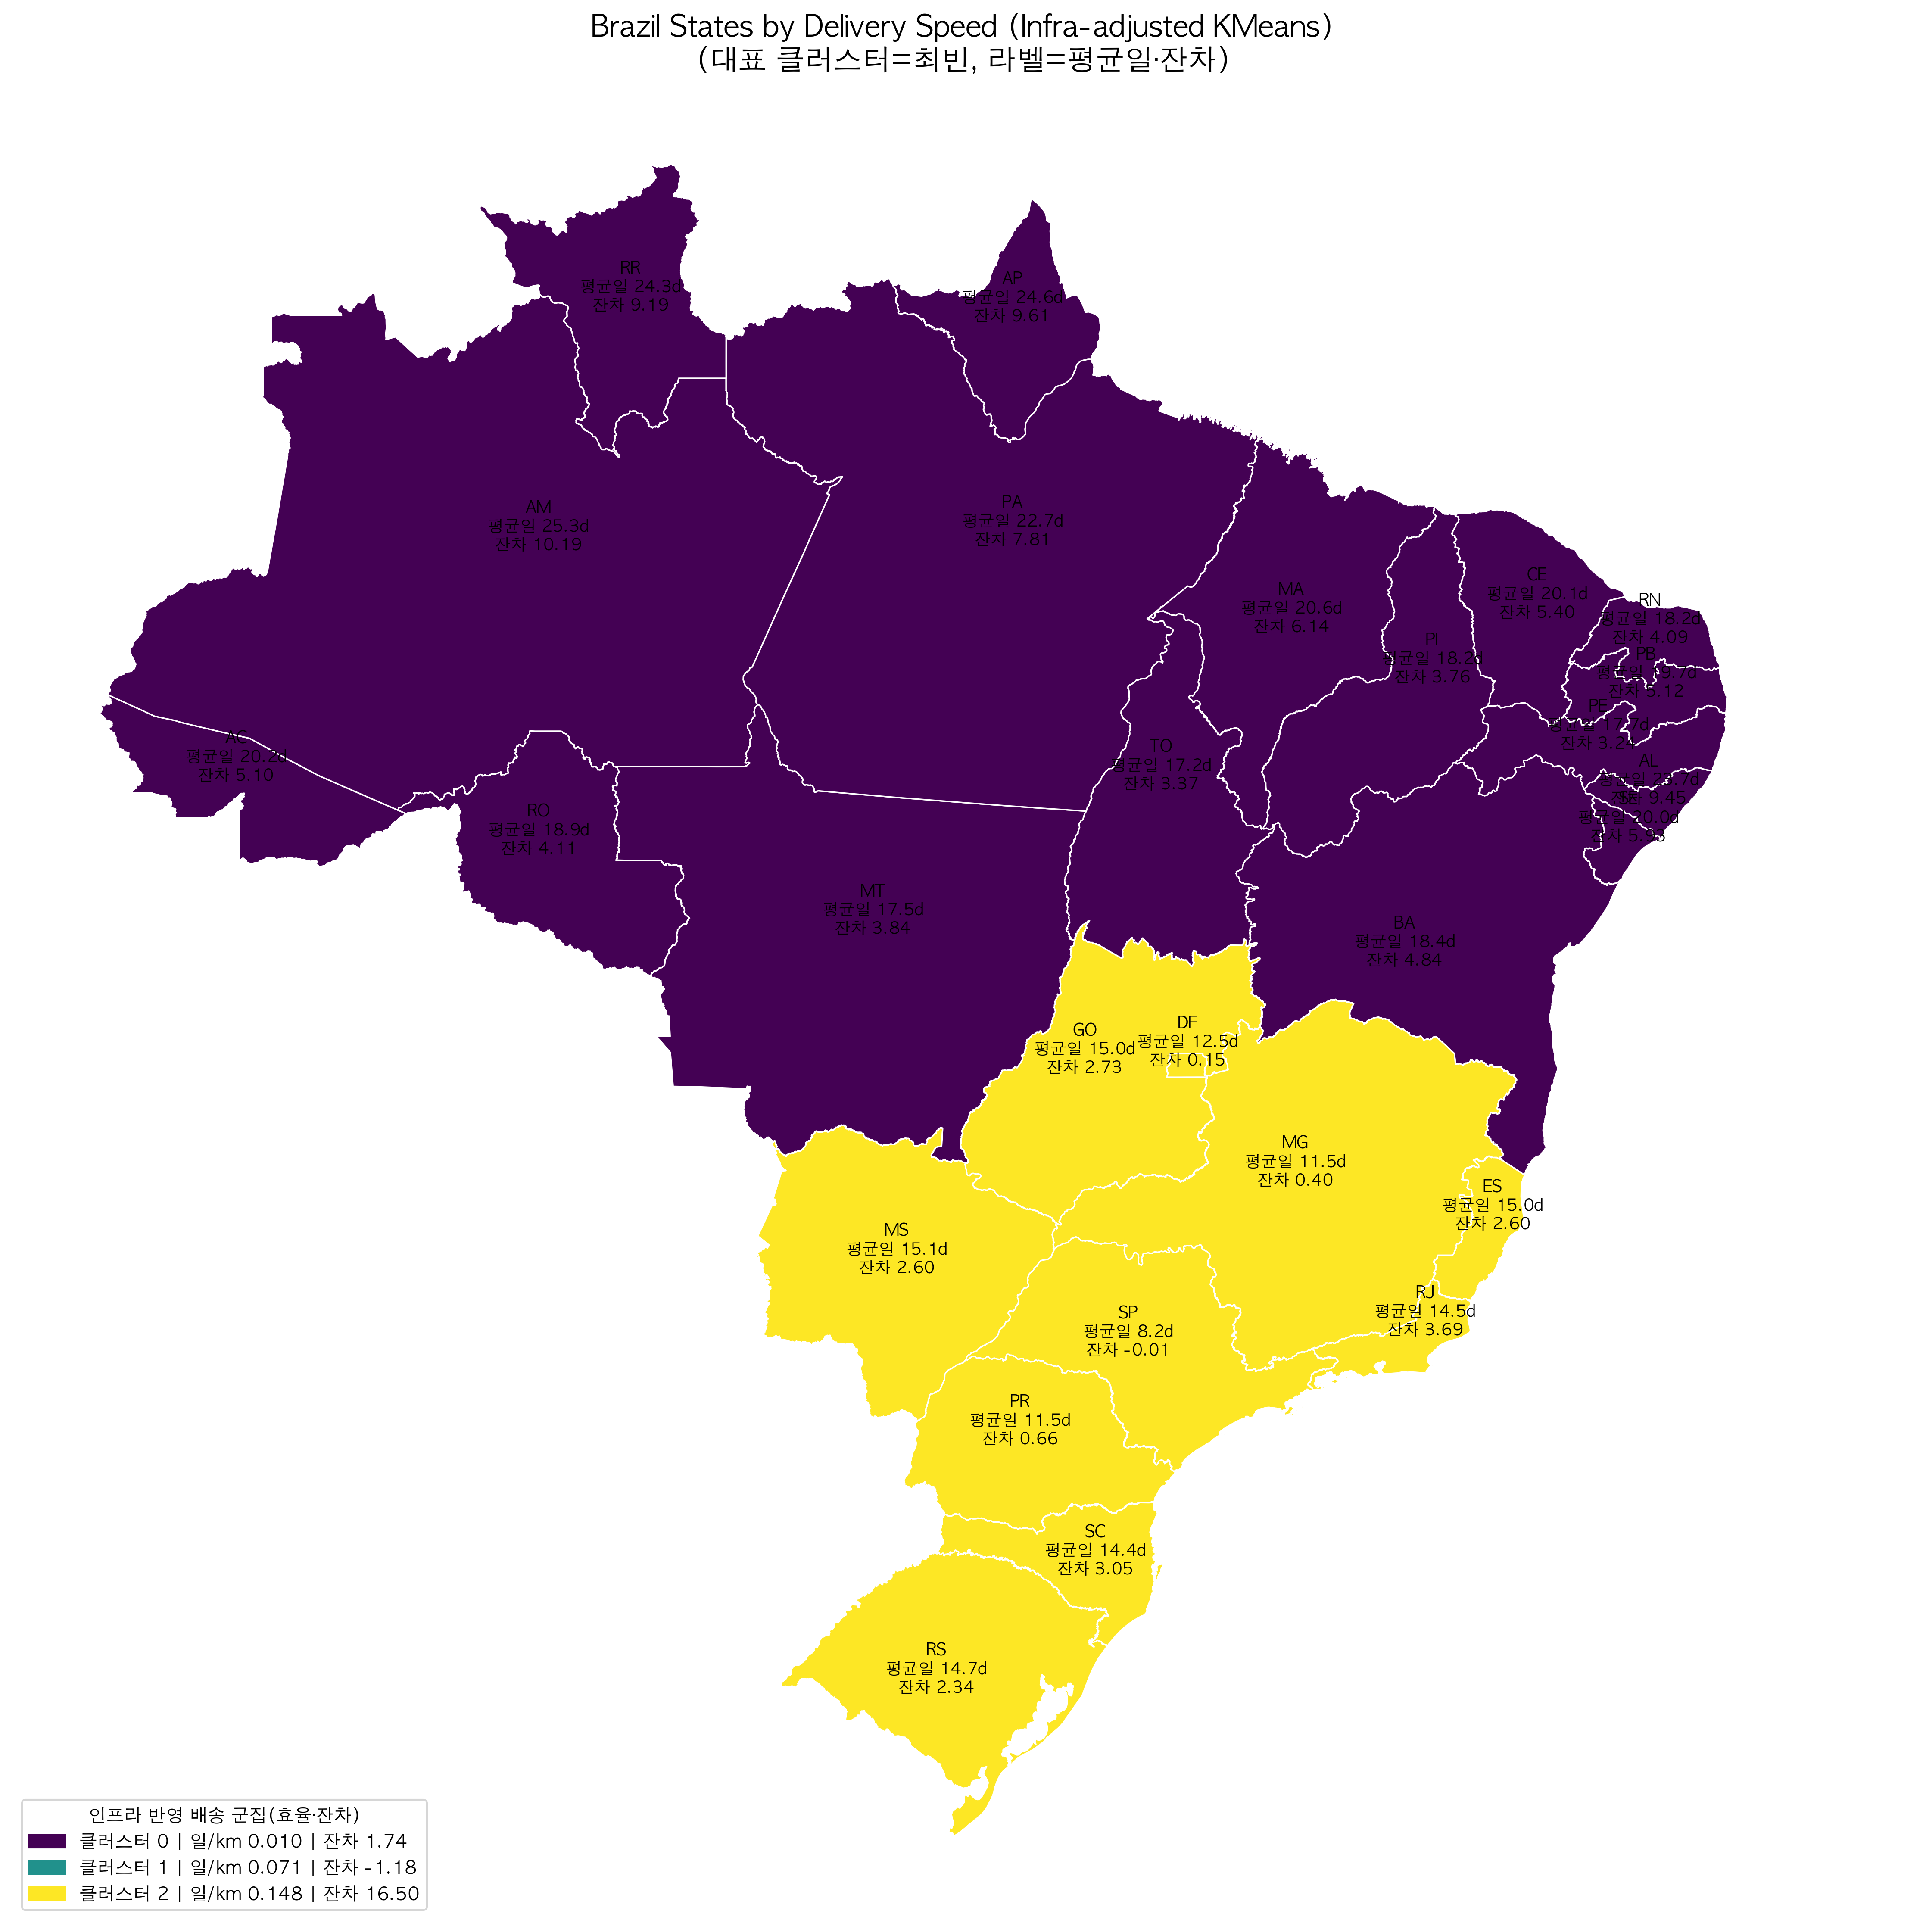

In [16]:
from math import radians, sin, cos, asin, sqrt

# 거리 계산 함수
def haversine (lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return float('nan')
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*asin(sqrt(a))

order_items_df = items_df

# 2.5) 고객/셀러 좌표 붙이기 + 주문별 거리 계산  (NEW)
# ===============================
# geolocation_df: geolocation_zip_code_prefix, geolocation_lat, geolocation_lng
geo = geolocation_df.drop_duplicates('geolocation_zip_code_prefix').rename(
    columns={'geolocation_zip_code_prefix':'zip_prefix',
             'geolocation_lat':'lat', 'geolocation_lng':'lng'}
)

cust_xy = customers_df.rename(columns={'customer_zip_code_prefix':'zip_prefix'}) \
    .merge(geo, on='zip_prefix', how='left') \
    .rename(columns={'lat':'cust_lat','lng':'cust_lng'}) \
    [['customer_id','customer_state','cust_lat','cust_lng']]

sell_xy = sellers_df.rename(columns={'seller_zip_code_prefix':'zip_prefix'}) \
    .merge(geo, on='zip_prefix', how='left') \
    .rename(columns={'lat':'sell_lat','lng':'sell_lng'}) \
    [['seller_id','sell_lat','sell_lng']]

# 주문–셀러 매핑(한 주문에 여러 셀러 가능 → 평균거리로 대표)
oi = items_df[['order_id','seller_id']].drop_duplicates().merge(sell_xy, on='seller_id', how='left')
ord_base = orders[['order_id','customer_id','delivery_days']].merge(cust_xy, on='customer_id', how='left')

od = oi.merge(ord_base, on='order_id', how='left')
od['distance_km'] = od.apply(lambda r: haversine(r['cust_lat'], r['cust_lng'], r['sell_lat'], r['sell_lng']), axis=1)

order_dist = od.groupby('order_id', as_index=False)['distance_km'].mean()

# 주문 수준 테이블(배송일 + 거리 + 주)
order_level = orders[['order_id','customer_id','delivery_days']].merge(order_dist, on='order_id', how='left') \
    .merge(customers_df[['customer_id','customer_state']], on='customer_id', how='left')
order_level = order_level.dropna(subset=['delivery_days','distance_km','customer_state'])
order_level = order_level[(order_level['delivery_days']>=0) & (order_level['distance_km']>=0)].copy()

# 극단값 완화(옵션)
order_level['delivery_days'] = order_level['delivery_days'].clip(upper=order_level['delivery_days'].quantile(0.99))
order_level['distance_km']   = order_level['distance_km'].clip(upper=order_level['distance_km'].quantile(0.99))


# ===============================
# 3) 인프라 반영 지표 생성 
#    - efficiency = delivery_days / (distance_km + 1)
#    - infra_residual = 실제일수 - (거리로 예측한 기대일수)
# ===============================
order_level['efficiency'] = order_level['delivery_days'] / (order_level['distance_km'] + 1.0)

# Robust 회귀로 '거리→기대 배송일' 추정 (로그 스케일 권장)
X = np.log1p(order_level[['distance_km']].values)
y = order_level['delivery_days'].values
hub = HuberRegressor().fit(X, y)
order_level['expected_days'] = hub.predict(X)
order_level['infra_residual'] = order_level['delivery_days'] - order_level['expected_days']  # +면 인프라/운영 추가지연


# ===============================
# 4) 고객 단위 피처 집계 (NEW)
# ===============================
cd_with_state = order_level.groupby(['customer_id','customer_state'], as_index=False).agg(
    delivery_days=('delivery_days','mean'),
    distance_km=('distance_km','mean'),
    efficiency=('efficiency','mean'),
    infra_residual=('infra_residual','mean')
)

# ===============================
# 5) KMeans (인프라 반영 피처로)  (REPLACE)
# ===============================
feat_cols = ['delivery_days','distance_km','efficiency','infra_residual']
X = cd_with_state[feat_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cd_with_state['cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터별 요약(범례용)
cluster_summary = cd_with_state.groupby('cluster')[feat_cols].mean().reset_index()

# ===============================
# 6) 주(state) 단위 집계 (모드는 유지, 잔차 평균 추가)  (ADAPT)
# ===============================
def mode_cluster(s):
    return s.value_counts().idxmax() if len(s) > 0 else np.nan

state_agg = (
    cd_with_state.groupby('customer_state')
    .agg(
        state_cluster=('cluster', mode_cluster),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_infra_resid=('infra_residual','mean'),   # ← NEW: 거리로 설명 안 되는 초과지연
        n_customers=('customer_id', 'nunique')
    )
    .reset_index()
    .rename(columns={'customer_state': 'state'})
)

# ===============================
# 7) 지도 병합 & 시각화 (라벨에 잔차 표기)  (ADAPT)
# ===============================
merged = brazil.merge(state_agg, on='state', how='left')
merged_with_data = merged[~merged['state_cluster'].isna()].copy()

fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

cmap = mpl.cm.get_cmap('viridis', 3)
merged_with_data.plot(
    column='state_cluster',
    cmap=cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=False,
    categorical=True
)

for _, row in merged_with_data.iterrows():
    rep_pt = row['geometry'].representative_point()
    ax.text(
        rep_pt.x, rep_pt.y,
        f"{row['state']}\n평균일 {row['avg_delivery_days']:.1f}d\n잔차 {row['avg_infra_resid']:.2f}",
        fontsize=9, ha='center', weight='bold'
    )

# 커스텀 범례: 클러스터별 효율/잔차 평균
handles = []
N = 3
for _, r in cluster_summary.iterrows():
    c = int(r['cluster'])
    color = cmap(c/(N-1))
    handles.append(
        mpatches.Patch(
            color=color,
            label=(f"클러스터 {c} | 일/km {r['efficiency']:.3f} | 잔차 {r['infra_residual']:.2f}")
        )
    )
ax.legend(handles=handles, title="인프라 반영 배송 군집(효율·잔차)", loc='lower left')

plt.title("Brazil States by Delivery Speed (Infra-adjusted KMeans)\n(대표 클러스터=최빈, 라벨=평균일·잔차)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

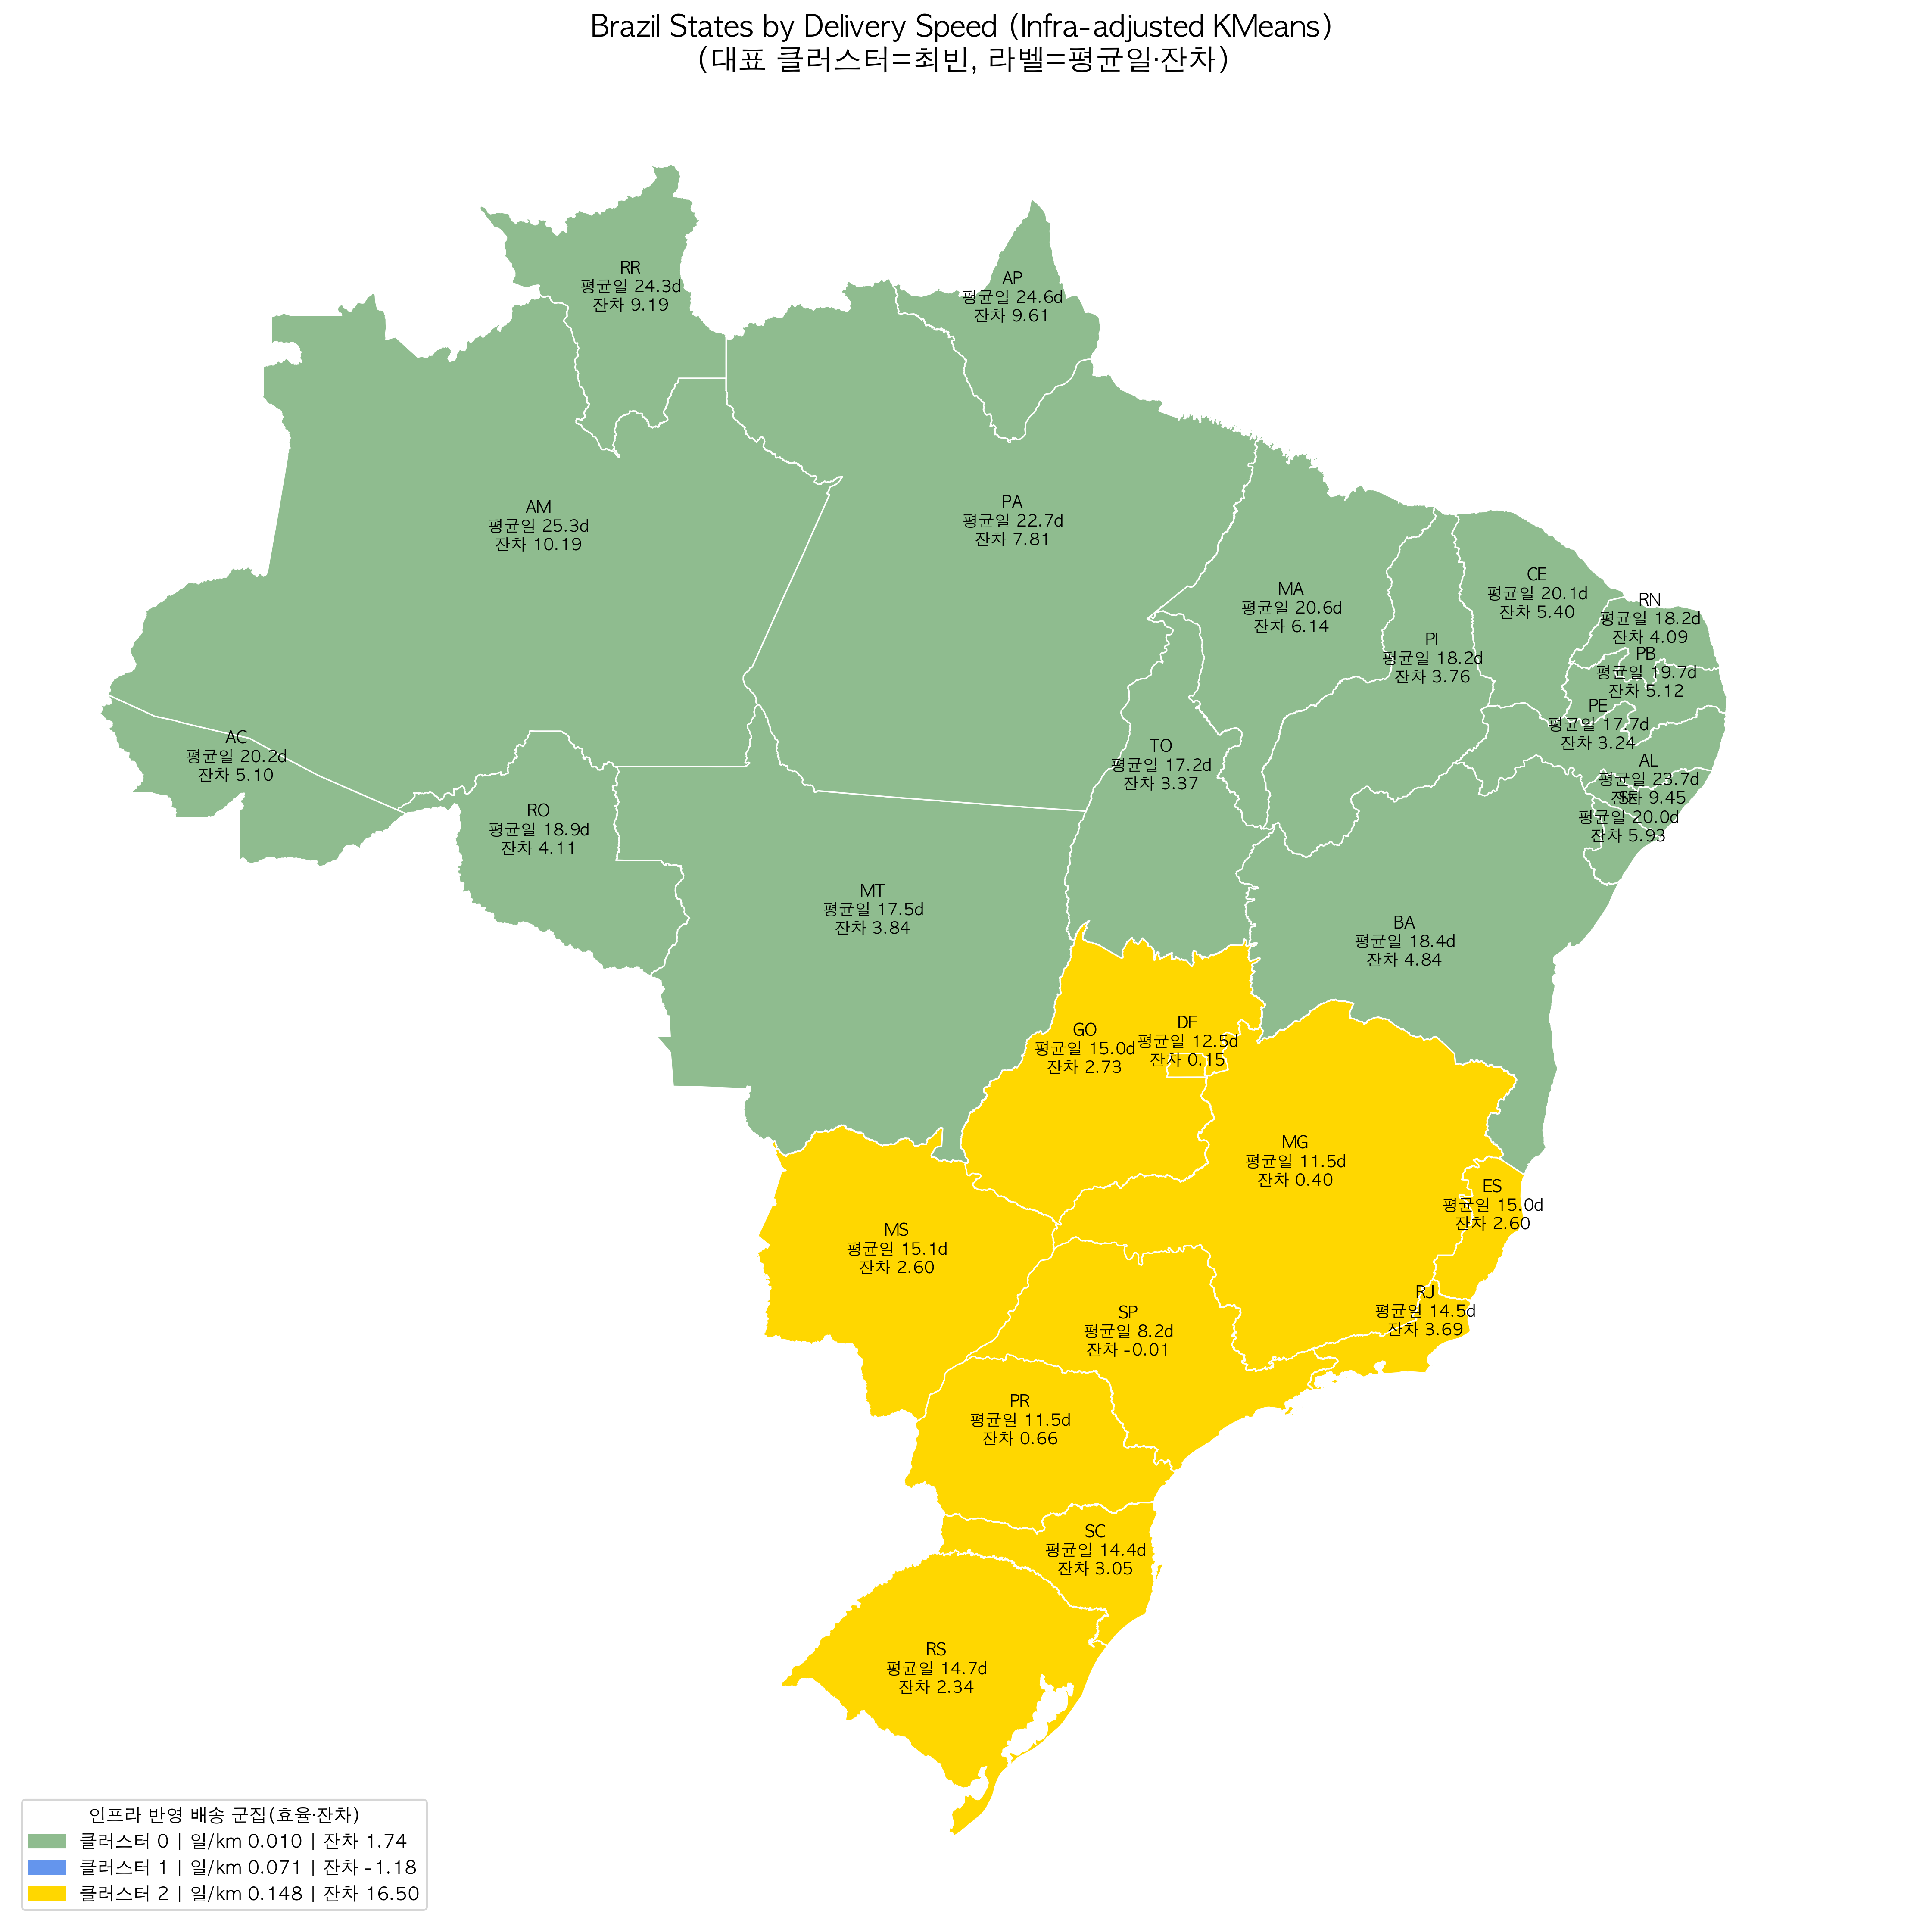

In [17]:
# 거리 계산 함수
def haversine (lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return float('nan')
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*asin(sqrt(a))

order_items_df = items_df

# 2.5) 고객/셀러 좌표 붙이기 + 주문별 거리 계산  (NEW)
# ===============================
# geolocation_df: geolocation_zip_code_prefix, geolocation_lat, geolocation_lng
geo = geolocation_df.drop_duplicates('geolocation_zip_code_prefix').rename(
    columns={'geolocation_zip_code_prefix':'zip_prefix',
             'geolocation_lat':'lat', 'geolocation_lng':'lng'}
)

cust_xy = customers_df.rename(columns={'customer_zip_code_prefix':'zip_prefix'}) \
    .merge(geo, on='zip_prefix', how='left') \
    .rename(columns={'lat':'cust_lat','lng':'cust_lng'}) \
    [['customer_id','customer_state','cust_lat','cust_lng']]

sell_xy = sellers_df.rename(columns={'seller_zip_code_prefix':'zip_prefix'}) \
    .merge(geo, on='zip_prefix', how='left') \
    .rename(columns={'lat':'sell_lat','lng':'sell_lng'}) \
    [['seller_id','sell_lat','sell_lng']]

# 주문–셀러 매핑(한 주문에 여러 셀러 가능 → 평균거리로 대표)
oi = items_df[['order_id','seller_id']].drop_duplicates().merge(sell_xy, on='seller_id', how='left')
ord_base = orders[['order_id','customer_id','delivery_days']].merge(cust_xy, on='customer_id', how='left')

od = oi.merge(ord_base, on='order_id', how='left')
od['distance_km'] = od.apply(lambda r: haversine(r['cust_lat'], r['cust_lng'], r['sell_lat'], r['sell_lng']), axis=1)

order_dist = od.groupby('order_id', as_index=False)['distance_km'].mean()

# 주문 수준 테이블(배송일 + 거리 + 주)
order_level = orders[['order_id','customer_id','delivery_days']].merge(order_dist, on='order_id', how='left') \
    .merge(customers_df[['customer_id','customer_state']], on='customer_id', how='left')
order_level = order_level.dropna(subset=['delivery_days','distance_km','customer_state'])
order_level = order_level[(order_level['delivery_days']>=0) & (order_level['distance_km']>=0)].copy()

# 극단값 완화(옵션)
order_level['delivery_days'] = order_level['delivery_days'].clip(upper=order_level['delivery_days'].quantile(0.99))
order_level['distance_km']   = order_level['distance_km'].clip(upper=order_level['distance_km'].quantile(0.99))


# ===============================
# 3) 인프라 반영 지표 생성 
#    - efficiency = delivery_days / (distance_km + 1)
#    - infra_residual = 실제일수 - (거리로 예측한 기대일수)
# ===============================
order_level['efficiency'] = order_level['delivery_days'] / (order_level['distance_km'] + 1.0)

# Robust 회귀로 '거리→기대 배송일' 추정 (로그 스케일 권장)
X = np.log1p(order_level[['distance_km']].values)
y = order_level['delivery_days'].values
hub = HuberRegressor().fit(X, y)
order_level['expected_days'] = hub.predict(X)
order_level['infra_residual'] = order_level['delivery_days'] - order_level['expected_days']  # +면 인프라/운영 추가지연


# ===============================
# 4) 고객 단위 피처 집계 (NEW)
# ===============================
cd_with_state = order_level.groupby(['customer_id','customer_state'], as_index=False).agg(
    delivery_days=('delivery_days','mean'),
    distance_km=('distance_km','mean'),
    efficiency=('efficiency','mean'),
    infra_residual=('infra_residual','mean')
)

# ===============================
# 5) KMeans (인프라 반영 피처로)  (REPLACE)
# ===============================
feat_cols = ['delivery_days','distance_km','efficiency','infra_residual']
X = cd_with_state[feat_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cd_with_state['cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터별 요약(범례용)
cluster_summary = cd_with_state.groupby('cluster')[feat_cols].mean().reset_index()

# ===============================
# 6) 주(state) 단위 집계 (모드는 유지, 잔차 평균 추가)  (ADAPT)
# ===============================
def mode_cluster(s):
    return s.value_counts().idxmax() if len(s) > 0 else np.nan

state_agg = (
    cd_with_state.groupby('customer_state')
    .agg(
        state_cluster=('cluster', mode_cluster),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_infra_resid=('infra_residual','mean'),   # ← NEW: 거리로 설명 안 되는 초과지연
        n_customers=('customer_id', 'nunique')
    )
    .reset_index()
    .rename(columns={'customer_state': 'state'})
)


# ===============================
# 7) 지도 병합 & 시각화 (라벨에 잔차 표기)  (ADAPT)
# ===============================
from matplotlib.colors import ListedColormap
merged = brazil.merge(state_agg, on='state', how='left')
merged_with_data = merged[~merged['state_cluster'].isna()].copy()

fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

# 👉 보라색 대신 밝은 초록(#8FBC8F)으로 custom cmap 지정
custom_cmap = ListedColormap(["#8FBC8F", "#6495ED", "#FFD700"])  

merged_with_data.plot(
    column='state_cluster',
    cmap=custom_cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=False,
    categorical=True
)

for _, row in merged_with_data.iterrows():
    rep_pt = row['geometry'].representative_point()
    ax.text(
        rep_pt.x, rep_pt.y,
        f"{row['state']}\n평균일 {row['avg_delivery_days']:.1f}d\n잔차 {row['avg_infra_resid']:.2f}",
        fontsize=9, ha='center', weight='bold'
    )

# 커스텀 범례: 클러스터별 효율/잔차 평균
cluster_colors = {
    0: "#8FBC8F",  # 초록
    1: "#6495ED",  # 파랑
    2: "#FFD700",  # 노랑
}

# 범례 다시 만들기
handles = []
for _, r in cluster_summary.iterrows():
    c = int(r['cluster'])
    color = cluster_colors[c]   # 직접 매핑된 색 사용
    handles.append(
        mpatches.Patch(
            color=color,
            label=(f"클러스터 {c} | 일/km {r['efficiency']:.3f} | 잔차 {r['infra_residual']:.2f}")
        )
    )

ax.legend(handles=handles, title="인프라 반영 배송 군집(효율·잔차)", loc='lower left')

plt.title("Brazil States by Delivery Speed (Infra-adjusted KMeans)\n(대표 클러스터=최빈, 라벨=평균일·잔차)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()


In [18]:
green_states = state_agg[state_agg['state_cluster'] == 0]['state']

# order_level 기준으로 주문량 집계
green_order_counts = (
    order_level[order_level['customer_state'].isin(green_states)]
    .groupby('customer_state')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'num_orders'})
    .sort_values('num_orders', ascending=False))

green_order_counts

,customer_state,num_orders
4,BA,3238
10,PE,1588
5,CE,1272
8,PA,944
7,MT,881
6,MA,713
9,PB,511
11,PI,473
12,RN,472
1,AL,396


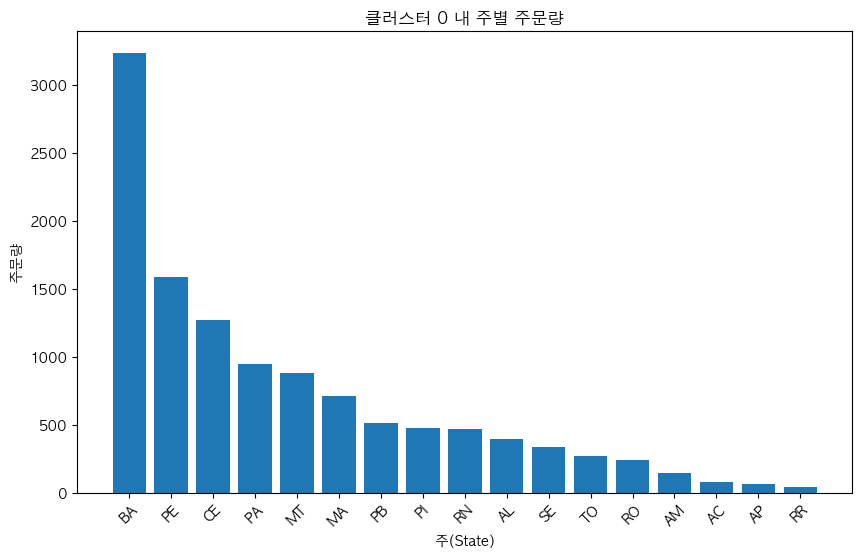

In [19]:
plt.figure(figsize=(10,6))
plt.bar(green_order_counts['customer_state'], green_order_counts['num_orders'])
plt.title("클러스터 0 내 주별 주문량")
plt.xlabel("주(State)")
plt.ylabel("주문량")
plt.xticks(rotation=45)
plt.show()

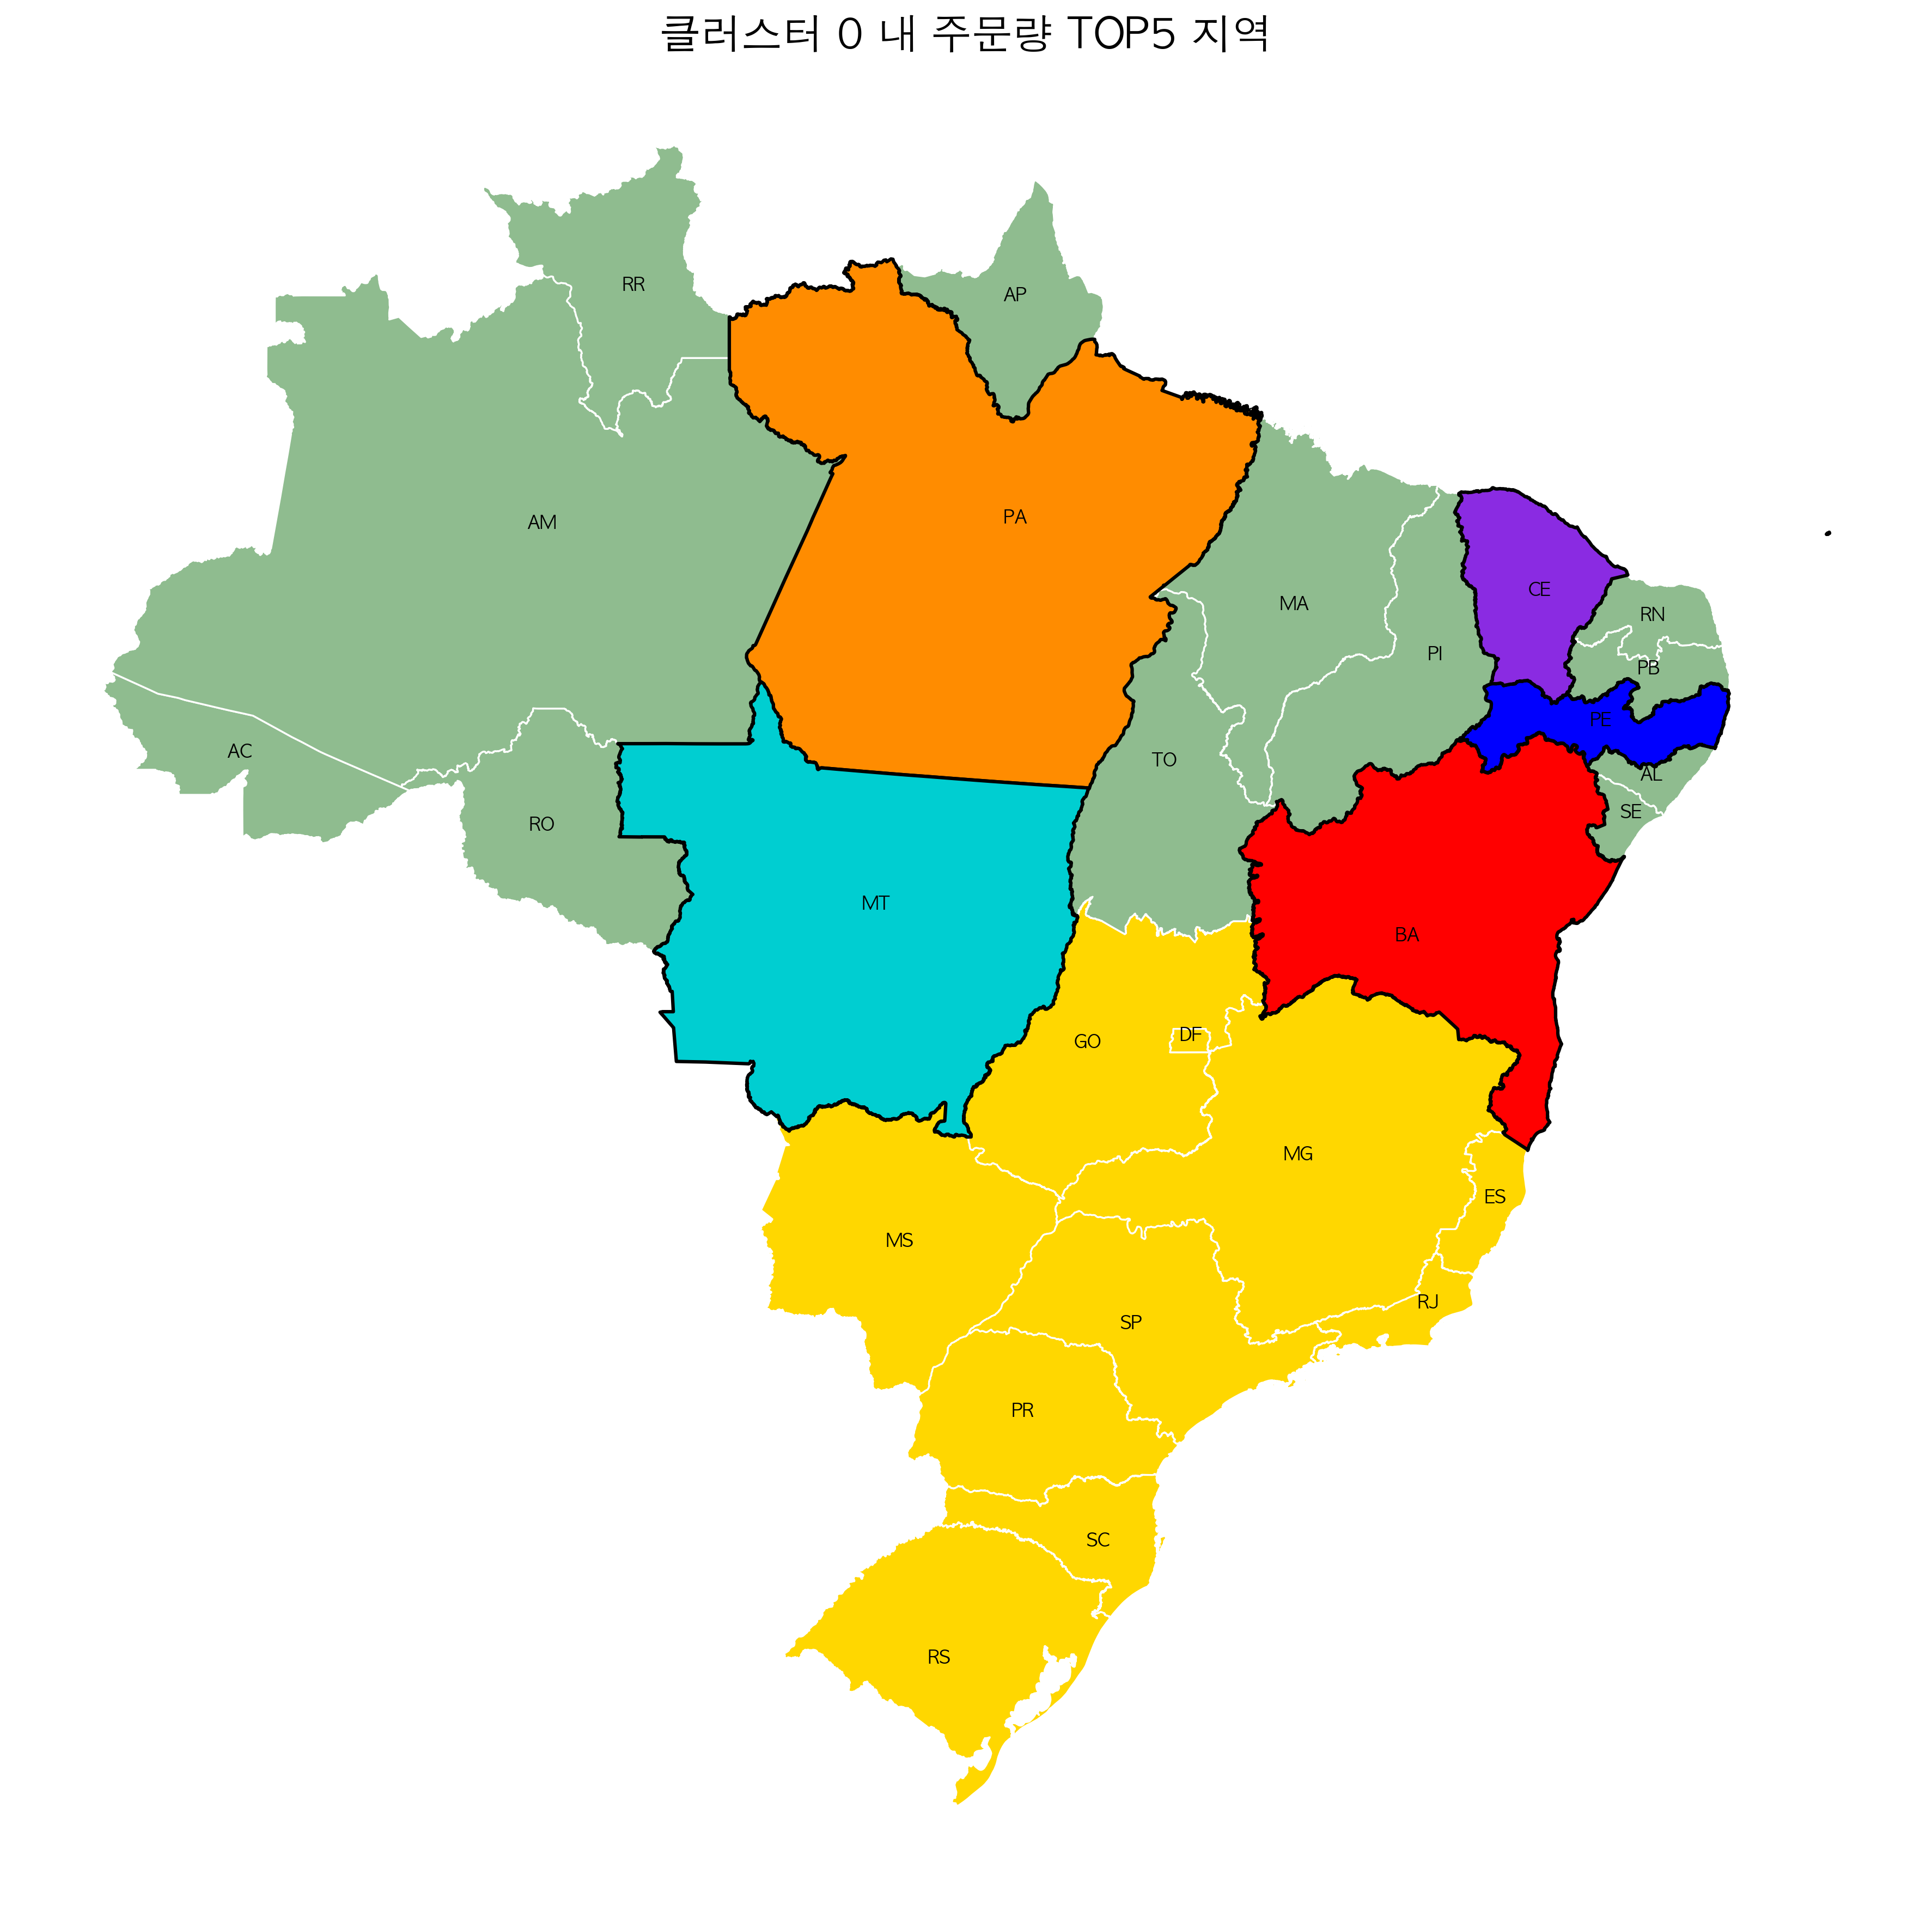

In [12]:
top5_states = green_order_counts.head(5)['customer_state'].tolist()

# 2) 기본 지도 (초록/노랑)
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')

cmap = mpl.colors.ListedColormap(["#8FBC8F", "#FFD700"])  # 초록, 노랑
merged_with_data.plot(
    column='state_cluster',
    cmap=cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=False,
    categorical=True
)

# 3) TOP5 주문량 많은 주만 강조 색상 지정
highlight_colors = ["#FF0000", "#0000FF", "#8A2BE2", "#FF8C00", "#00CED1"]  # 빨강, 파랑, 보라, 주황, 청록
for i, state in enumerate(top5_states):
    row = merged_with_data[merged_with_data['state'] == state]
    row.plot(ax=ax, color=highlight_colors[i], edgecolor="black", linewidth=1.5)


# 4) 라벨 다시 표시
for _, row in merged_with_data.iterrows():
    rep_pt = row['geometry'].representative_point()
    ax.text(
        rep_pt.x, rep_pt.y,
        f"{row['state']}",
        fontsize=8, ha='center', weight='bold'
    )

plt.title("클러스터 0 내 주문량 TOP5 지역", fontsize=18)
ax.axis('off')
plt.savefig('클러스터 0 내 주문량 TOP5 지역', dpi=600)
plt.show()


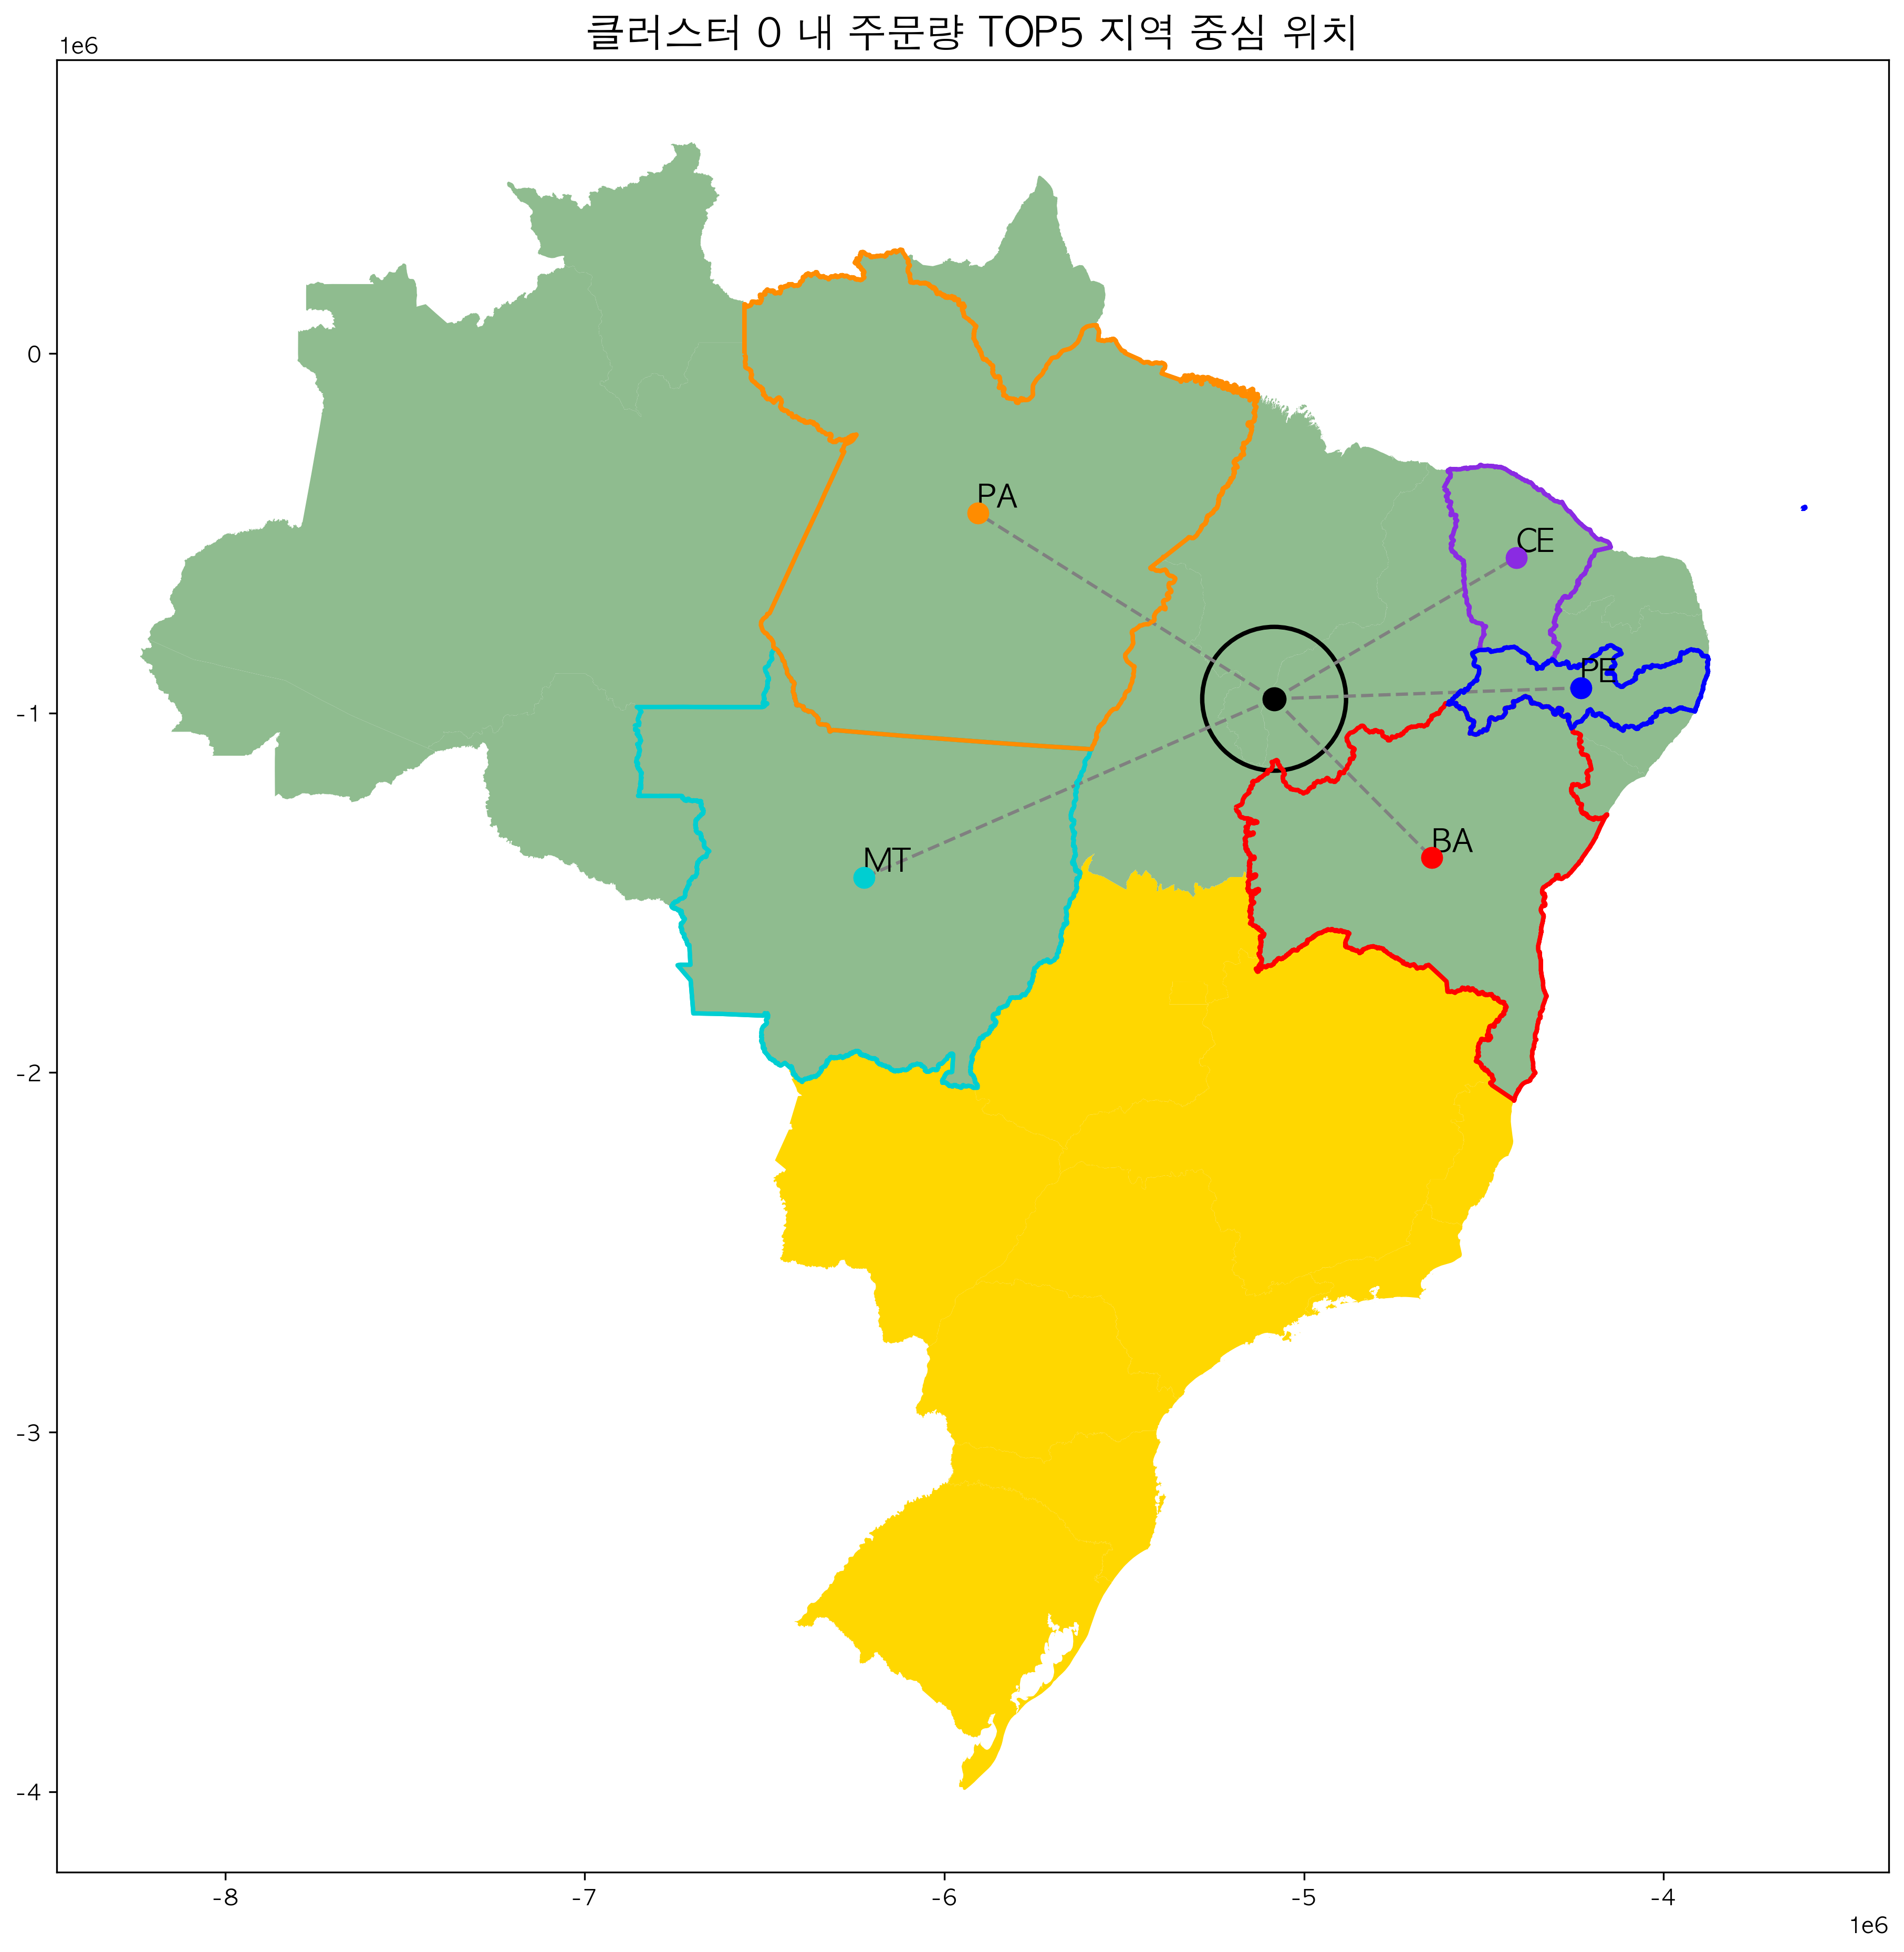

In [23]:
# GeoDataFrame은 미리 같은 투영계로 맞춰주기
merged_with_data = merged_with_data.to_crs(epsg=3857)
brazil = brazil.to_crs(epsg=3857)

top5_rows = merged_with_data[merged_with_data['state'].isin(top5_states)].copy()
top5_rows['centroid'] = top5_rows['geometry'].centroid
top5_rows['x'] = top5_rows['centroid'].x
top5_rows['y'] = top5_rows['centroid'].y

center_x = top5_rows['x'].mean()
center_y = top5_rows['y'].mean()

fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')
merged_with_data.plot(column='state_cluster', cmap=custom_cmap, ax=ax, legend=False)

highlight_colors = ["#FF0000", "#8A2BE2", "#00CED1", "#FF8C00", "#0000FF"]

for i, (_, row) in enumerate(top5_rows.iterrows()):
    gpd.GeoSeries([row.geometry.boundary]).plot(ax=ax, color=highlight_colors[i], linewidth=2)
    ax.scatter(row['x'], row['y'], color=highlight_colors[i], s=80, zorder=5)

# 중심점
ax.scatter(center_x, center_y, color="black", s=100, marker="o", zorder=6)
circle = plt.Circle((center_x, center_y), 2e5, color="black", fill=False, linewidth=2)  # 반경 조정
ax.add_patch(circle)

for _, row in top5_rows.iterrows():
    ax.plot([center_x, row['x']], [center_y, row['y']], color="gray", linestyle="--")

for i, (_, row) in enumerate(top5_rows.iterrows()):
    # 경계선 강조
    gpd.GeoSeries([row.geometry.boundary]).plot(ax=ax, color=highlight_colors[i], linewidth=2)
    
    # 중심점 찍기
    ax.scatter(row['x'], row['y'], color=highlight_colors[i], s=80, zorder=5)
    
    # 주 이름 크게, 검은색으로 표시
    ax.text(
        row['x'], row['y'], row['state'],  
        fontsize=14, color="black", weight="bold",
        ha="left", va="bottom"
    )

plt.title('클러스터 0 내 주문량 TOP5 지역 중심 위치', fontsize=18)
plt.savefig('클러스터 0 내 주문량 TOP5 지역 중심 위치', dpi=600)

In [25]:
# 1) 클러스터 0에 속한 state 추출
green_states = state_agg[state_agg['state_cluster'] == 0]['state']

# 2) 주문량 기준 TOP5 주 뽑기
green_order_counts = (
    order_level[order_level['customer_state'].isin(green_states)]
    .groupby('customer_state')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'num_orders'})
    .sort_values('num_orders', ascending=False)
)

top5_states = green_order_counts.head(5)['customer_state'].tolist()

검은 점이 위치한 주: PI


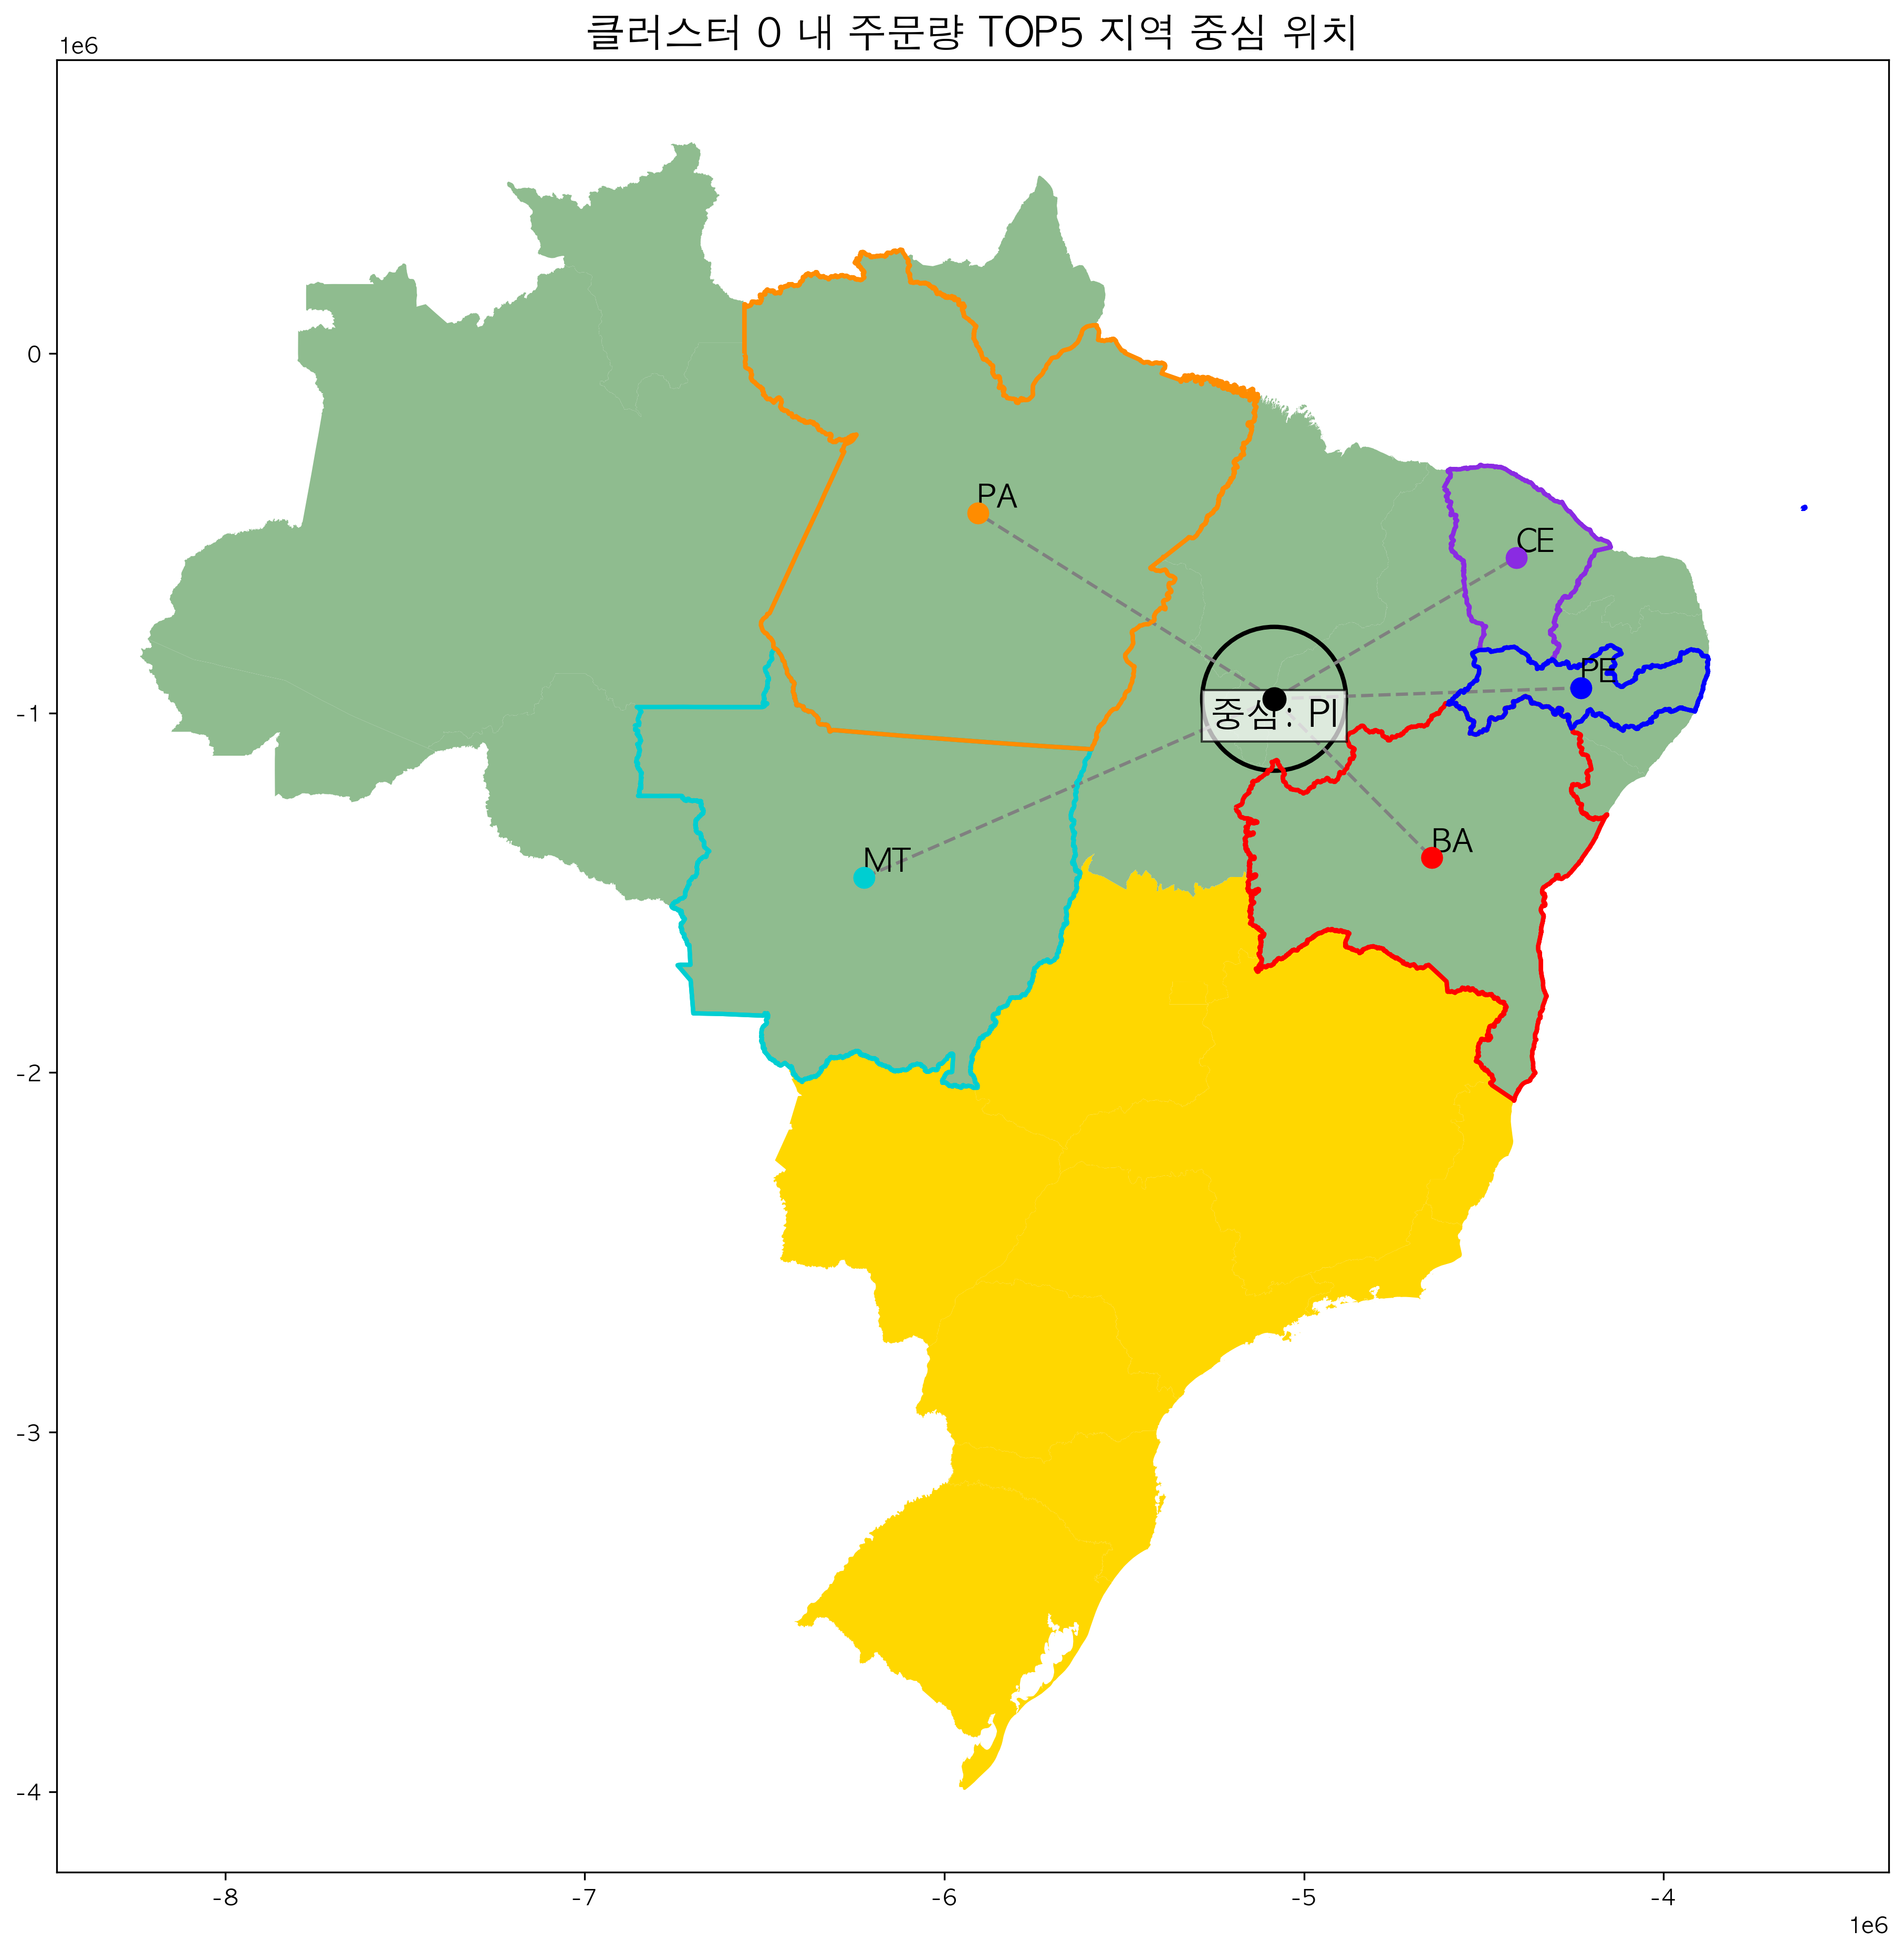

In [29]:
# GeoDataFrame은 미리 같은 투영계로 맞춰주기
merged_with_data = merged_with_data.to_crs(epsg=3857)
brazil = brazil.to_crs(epsg=3857)

top5_rows = merged_with_data[merged_with_data['state'].isin(top5_states)].copy()
top5_rows['centroid'] = top5_rows['geometry'].centroid
top5_rows['x'] = top5_rows['centroid'].x
top5_rows['y'] = top5_rows['centroid'].y

center_x = top5_rows['x'].mean()
center_y = top5_rows['y'].mean()

fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=300)
brazil.plot(ax=ax, color='#EEEEEE', edgecolor='white')
merged_with_data.plot(column='state_cluster', cmap=custom_cmap, ax=ax, legend=False)

highlight_colors = ["#FF0000", "#8A2BE2", "#00CED1", "#FF8C00", "#0000FF"]

for i, (_, row) in enumerate(top5_rows.iterrows()):
    gpd.GeoSeries([row.geometry.boundary]).plot(ax=ax, color=highlight_colors[i], linewidth=2)
    ax.scatter(row['x'], row['y'], color=highlight_colors[i], s=80, zorder=5)

# 중심점
ax.scatter(center_x, center_y, color="black", s=100, marker="o", zorder=6)
circle = plt.Circle((center_x, center_y), 2e5, color="black", fill=False, linewidth=2)  # 반경 조정
ax.add_patch(circle)

for _, row in top5_rows.iterrows():
    ax.plot([center_x, row['x']], [center_y, row['y']], color="gray", linestyle="--")

for i, (_, row) in enumerate(top5_rows.iterrows()):
    # 경계선 강조
    gpd.GeoSeries([row.geometry.boundary]).plot(ax=ax, color=highlight_colors[i], linewidth=2)
    
    # 중심점 찍기
    ax.scatter(row['x'], row['y'], color=highlight_colors[i], s=80, zorder=5)
    
    # 주 이름 크게, 검은색으로 표시
    ax.text(
        row['x'], row['y'], row['state'],  
        fontsize=14, color="black", weight="bold",
        ha="left", va="bottom"
    )

plt.title('클러스터 0 내 주문량 TOP5 지역 중심 위치', fontsize=18)

from shapely.geometry import Point

center_point = Point(center_x, center_y)
center_state = None
for idx, row in brazil.iterrows():
    if row['geometry'].contains(center_point):
        center_state = row['state']
        print("검은 점이 위치한 주:", center_state)
        break

# 중심점 텍스트 표시
if center_state:
    ax.text(
        center_x, center_y, f"중심: {center_state}",
        fontsize=16, color="black", weight="bold",
        ha="center", va="top", bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )

plt.savefig('클러스터 0 내 주문량 TOP5 중심 주')